In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


%matplotlib inline

In [ ]:
import os
from PIL import Image
from torchvision import transforms


test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def load_and_preprocess_test_images(folder_path):
    """
    Loads all images from a folder, converts to RGB, applies transforms.
    
    Args:
        folder_path (str): Path to test images folder.
    
    Returns:
        images (list of tensors): Preprocessed image tensors.
        image_names (list of str): Corresponding filenames.
    """
    images = []
    image_names = []
    
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder_path, filename)
            img = Image.open(img_path).convert("RGB")  # convert PNG with alpha to RGB
            img_tensor = test_transforms(img)
            images.append(img_tensor)
            image_names.append(filename)
    
    return images, image_names

# Mount Google Drive and set paths

from google.colab import drive
drive.mount('/content/drive')

test_folder = '/content/drive/MyDrive/ColabNotebooks/document-classifier/data/test'

# Load and preprocess test images
test_images, test_image_names = load_and_preprocess_test_images(test_folder)
print(f"Loaded {len(test_images)} test images from Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 10 test images from Drive


In [7]:
# Load Trained Model for Inference
import torch
from torchvision import models
import torch.nn as nn

model_path = '/content/drive/MyDrive/ColabNotebooks/document-classifier/models/trained_models/best_resnet18.pth'
num_classes = 10 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load checkpoint
checkpoint = torch.load(model_path, map_location=device)


model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)


model.eval()

print(f"Model loaded from epoch {checkpoint.get('epoch', 'unknown')} and ready for inference on device: {device}")

Model loaded from epoch 18 and ready for inference on device: cuda


Image: resumetest1.jpg → Predicted: Scientific
Image: ltt1.png → Predicted: Letter
Image: advertismentTest1.jpg → Predicted: ADVE
Image: advertismentTest2.jpg → Predicted: ADVE
Image: newspaperTest1.jpg → Predicted: Note
Image: newspaperTest2.jpg → Predicted: Memo
Image: scientificpaperTest1.png → Predicted: Memo
Image: resumeTest2.jpg → Predicted: Scientific
Image: noteTest2-modernNot1980s.png → Predicted: Resume
Image: noteTest1-itisrealyhard.png → Predicted: Resume


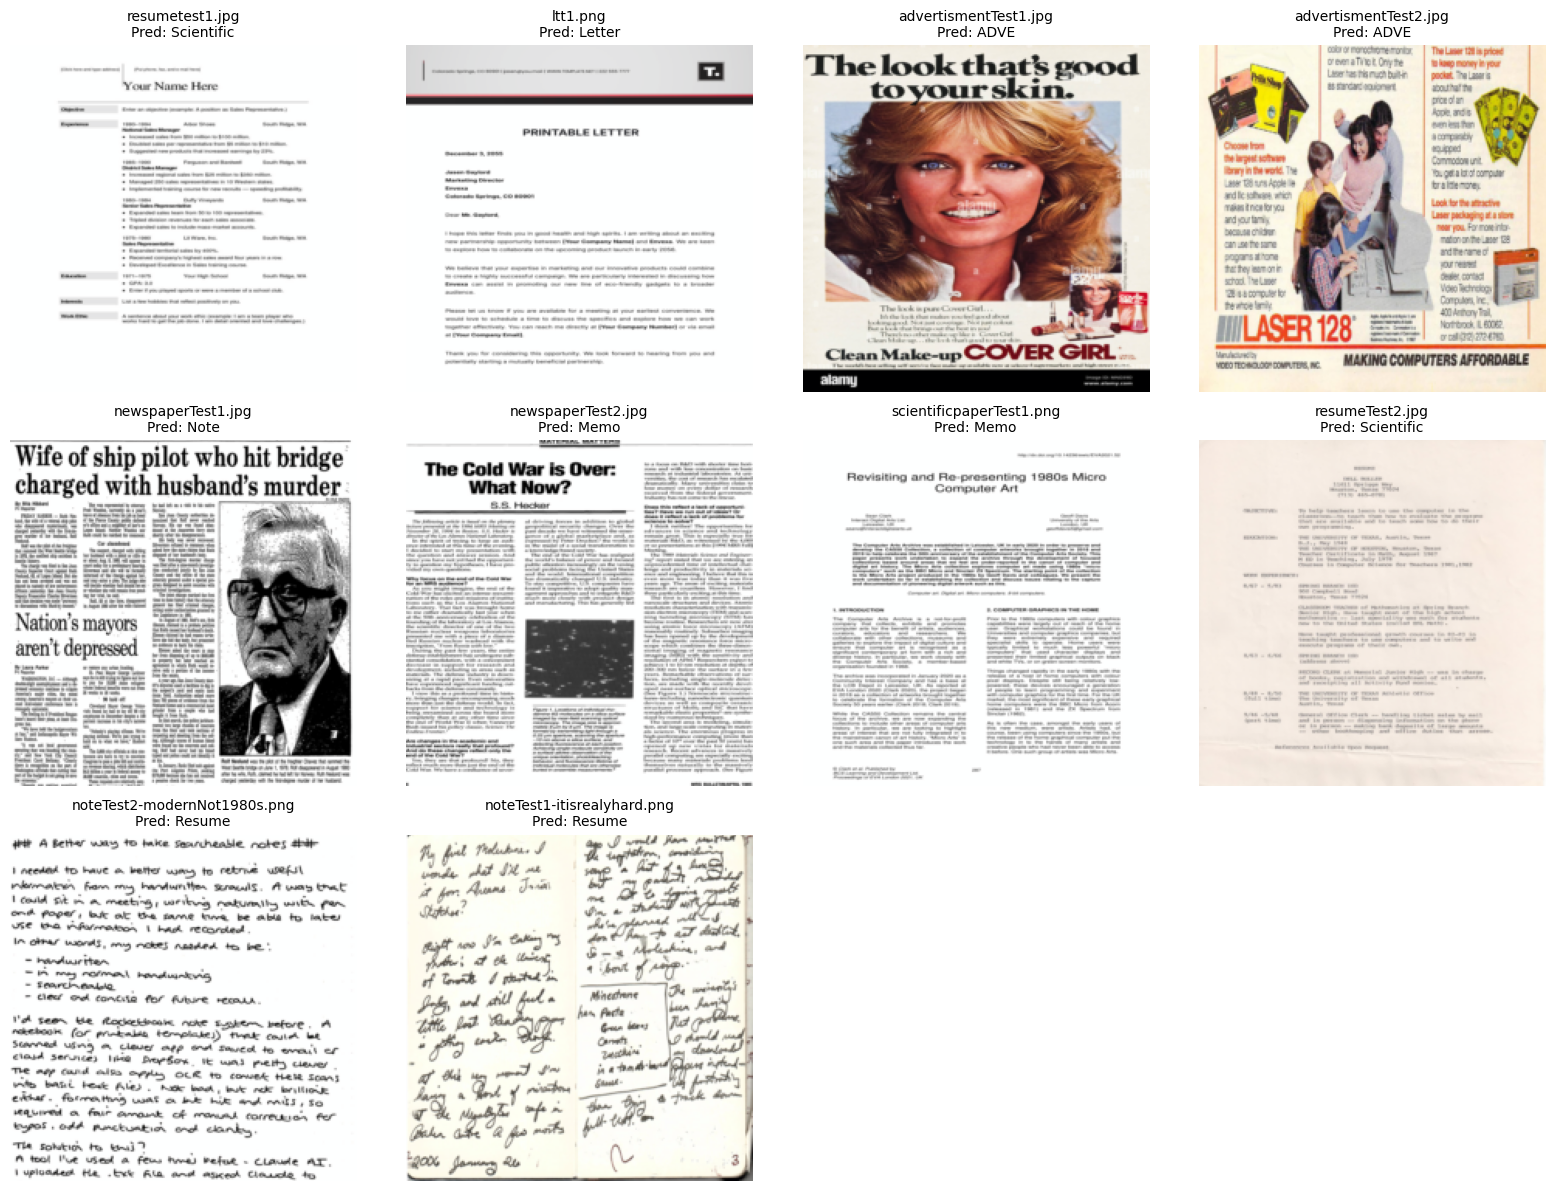

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from math import ceil


# Predict a single image
def predict_image(model, image_tensor, device):
    """
    Predict the class of a single image tensor.
    """
    image_tensor = image_tensor.unsqueeze(0).to(device) 
    with torch.no_grad():
        outputs = model(image_tensor)
        _, pred = torch.max(outputs, 1)
    return pred.item()


class_names = [
    "ADVE", "Email", "Form", "Letter", "News",
    "Note", "Resume", "Report", "Scientific", "Memo"
]


# Run inference on test images

predictions = []
for img_tensor, img_name in zip(test_images, test_image_names):
    pred_idx = predict_image(model, img_tensor, device)
    pred_class = class_names[pred_idx]
    predictions.append((img_name, pred_class))
    print(f"Image: {img_name} → Predicted: {pred_class}")


# Display predictions
def show_predictions(images, image_names, preds, max_per_row=4):
    """
    Display all images with predicted labels in a notebook-friendly layout.
    
    - images: list of image tensors (C,H,W)
    - image_names: list of image filenames
    - preds: list of tuples (img_name, predicted_class)
    - max_per_row: number of images per row
    """
    n_images = len(images)
    n_rows = ceil(n_images / max_per_row)
    plt.figure(figsize=(4*max_per_row, 4*n_rows))

    for i in range(n_images):
        img = images[i].permute(1,2,0).numpy()  
        # Unnormalize 
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        
        plt.subplot(n_rows, max_per_row, i+1)
        plt.imshow(img)
        plt.title(f"{image_names[i]}\nPred: {preds[i][1]}", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# Show all predictions
show_predictions(test_images, test_image_names, predictions)


# Evaluate accuracy 
if 'gt_labels' in globals():
    correct = sum(1 for img_name, pred in predictions if gt_labels.get(img_name) == pred)
    total = len(predictions)
    acc = correct / total * 100
    print(f"Test Accuracy on {total} images: {acc:.2f}%")